In [47]:
from dotenv import load_dotenv
import os
import requests
import pandas as pd

load_dotenv()
API_KEY = os.getenv("MP_API_KEY")

url = "https://api.materialsproject.org/materials/summary/"
params = {
    "elements": "Si",
    "_limit": 1000,
    "_fields": "material_id,formula_pretty,band_gap,formation_energy_per_atom,density,volume,nsites"
}
headers = {"X-API-KEY": API_KEY}

response = requests.get(url, params=params, headers=headers)
data = response.json()
print(response.status_code)
print(list(data.keys()))

200
['data', 'meta']


In [48]:
df = pd.DataFrame(data["data"])
print(f"Collected {len(df)} materials")
df.head()

Collected 1000 materials


,nsites,formula_pretty,volume,density,material_id,formation_energy_per_atom,band_gap
0,8,Si,163.065268,2.288020,mp-1120447,0.372510,0.0000
1,100,Si,1793.764938,2.599954,mp-1244933,0.349291,0.0000
2,100,Si,1921.073773,2.427656,mp-1244971,0.316752,0.0031
3,100,Si,1750.972847,2.663495,mp-1244990,0.366274,0.0000
4,100,Si,1918.192245,2.431303,mp-1245041,0.310314,0.0276


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic info
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
df.describe()

nsites                         int64
formula_pretty                   str
volume                       float64
density                      float64
material_id                      str
formation_energy_per_atom    float64
band_gap                     float64
dtype: object

Missing values:
nsites                       0
formula_pretty               0
volume                       0
density                      0
material_id                  0
formation_energy_per_atom    0
band_gap                     0
dtype: int64

Basic statistics:


,nsites,volume,density,formation_energy_per_atom,band_gap
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,31.191000,604.979931,4.203930,-1.350018,2.060401
std,43.815115,894.484342,3.228427,1.438232,2.469270
min,1.000000,13.862998,0.102754,-3.839805,0.000000
25%,6.000000,120.466661,2.019270,-3.168151,0.000000
50%,12.000000,226.015115,2.699806,-0.719725,0.149600
75%,36.000000,673.075614,5.936394,-0.144890,5.355800
max,432.000000,6978.668766,18.208518,2.512267,7.717300


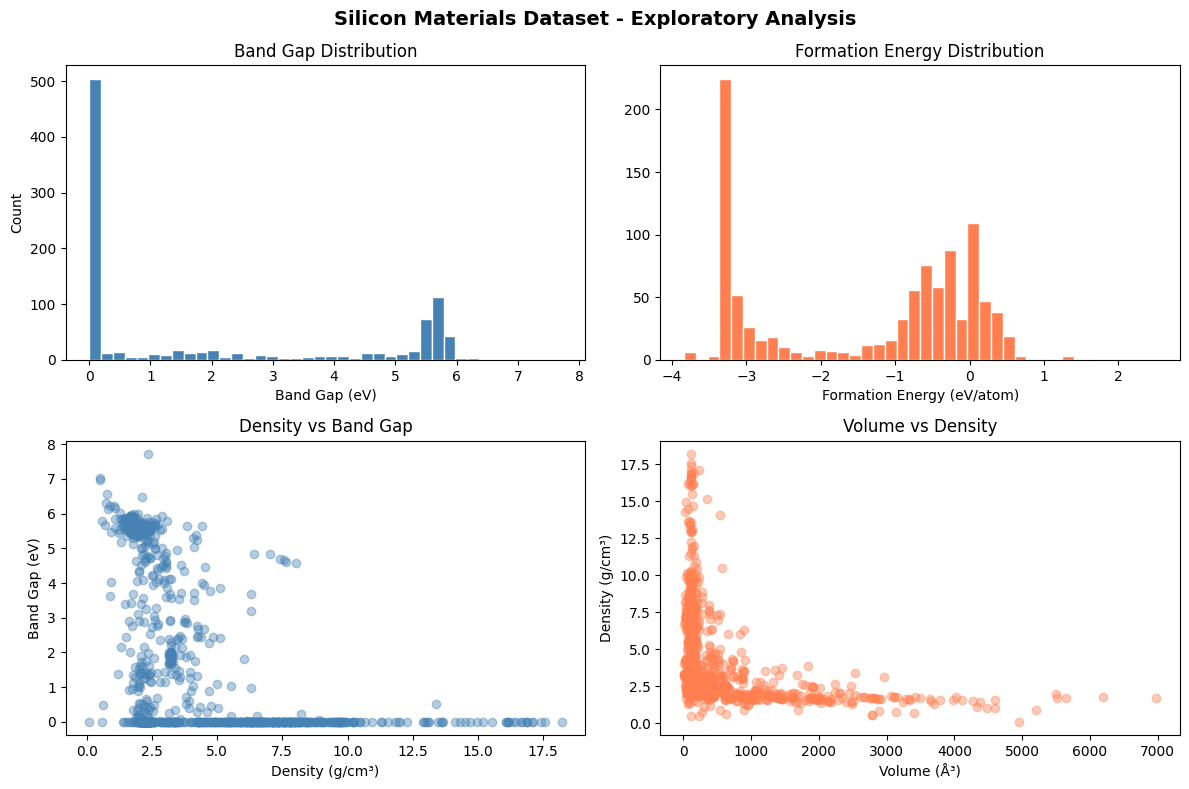

Plot saved!


In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Silicon Materials Dataset - Exploratory Analysis', fontsize=14, fontweight='bold')

# Band gap distribution
axes[0,0].hist(df['band_gap'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Band Gap Distribution')
axes[0,0].set_xlabel('Band Gap (eV)')
axes[0,0].set_ylabel('Count')

# Formation energy distribution
axes[0,1].hist(df['formation_energy_per_atom'], bins=40, color='coral', edgecolor='white')
axes[0,1].set_title('Formation Energy Distribution')
axes[0,1].set_xlabel('Formation Energy (eV/atom)')

# Density vs band gap
axes[1,0].scatter(df['density'], df['band_gap'], alpha=0.4, color='steelblue')
axes[1,0].set_title('Density vs Band Gap')
axes[1,0].set_xlabel('Density (g/cm³)')
axes[1,0].set_ylabel('Band Gap (eV)')

# Volume vs density
axes[1,1].scatter(df['volume'], df['density'], alpha=0.4, color='coral')
axes[1,1].set_title('Volume vs Density')
axes[1,1].set_xlabel('Volume (Å³)')
axes[1,1].set_ylabel('Density (g/cm³)')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [51]:
# Create metal vs non-metal label
df['is_metal'] = (df['band_gap'] == 0).astype(int)

print("Metal vs Non-metal counts:")
print(df['is_metal'].value_counts())
print(f"\nMetals: {df['is_metal'].sum()} ({df['is_metal'].mean()*100:.1f}%)")
print(f"Non-metals: {(1-df['is_metal']).sum()} ({(1-df['is_metal']).mean()*100:.1f}%)")

Metal vs Non-metal counts:
is_metal
0    511
1    489
Name: count, dtype: int64

Metals: 489 (48.9%)
Non-metals: 511 (51.1%)


Random Forest Classification Report:
              precision    recall  f1-score   support

   Non-metal       0.92      0.95      0.94       102
       Metal       0.95      0.92      0.93        98

    accuracy                           0.94       200
   macro avg       0.94      0.93      0.93       200
weighted avg       0.94      0.94      0.93       200



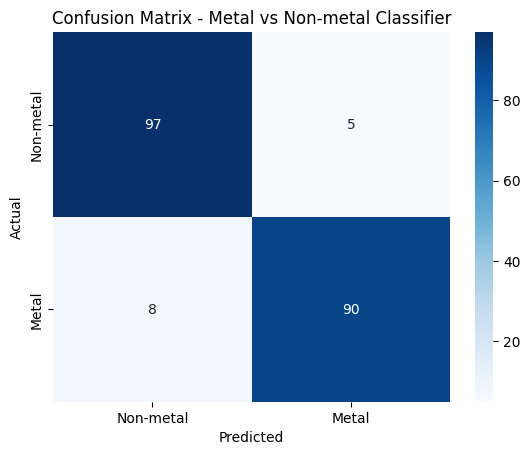

In [52]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Features and target
features = ['nsites', 'volume', 'density', 'formation_energy_per_atom']
X = df[features]
y = df['is_metal']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Results
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-metal', 'Metal']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-metal', 'Metal'],
            yticklabels=['Non-metal', 'Metal'])
plt.title('Confusion Matrix - Metal vs Non-metal Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

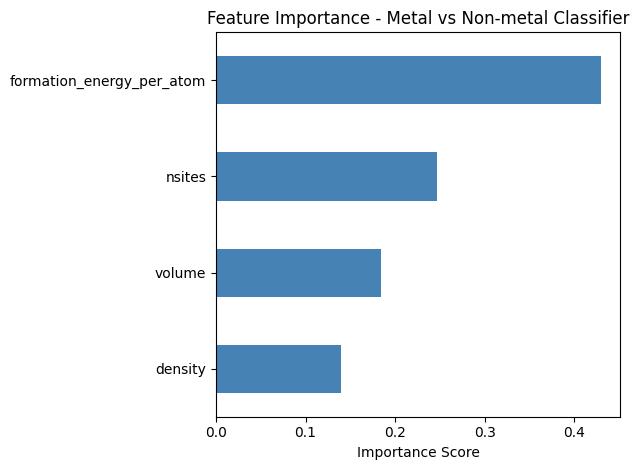


Feature Importances:
formation_energy_per_atom    0.429722
nsites                       0.246741
volume                       0.184310
density                      0.139227
dtype: float64


In [53]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Metal vs Non-metal Classifier')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature Importances:")
print(importances.sort_values(ascending=False))

Non-metal samples: 511

Band gap range: 0.00 to 7.72 eV
Mean band gap: 4.03 eV


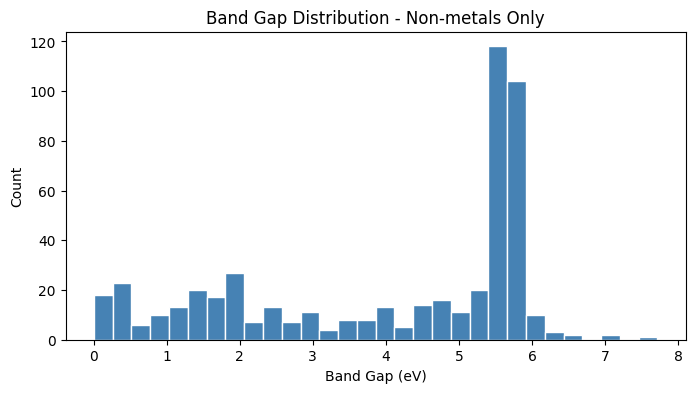

In [54]:
# Filter non-metals only
df_nonmetal = df[df['is_metal'] == 0].copy()
print(f"Non-metal samples: {len(df_nonmetal)}")
print(f"\nBand gap range: {df_nonmetal['band_gap'].min():.2f} to {df_nonmetal['band_gap'].max():.2f} eV")
print(f"Mean band gap: {df_nonmetal['band_gap'].mean():.2f} eV")

# Distribution
plt.figure(figsize=(8,4))
plt.hist(df_nonmetal['band_gap'], bins=30, color='steelblue', edgecolor='white')
plt.title('Band Gap Distribution - Non-metals Only')
plt.xlabel('Band Gap (eV)')
plt.ylabel('Count')
plt.savefig('bandgap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Features and target
X_reg = df_nonmetal[features]
y_reg = df_nonmetal['band_gap']

# Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Train both models and compare
models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_r, y_train_r)
    y_pred_r = model.predict(X_test_r)
    mae = mean_absolute_error(y_test_r, y_pred_r)
    r2 = r2_score(y_test_r, y_pred_r)
    print(f"{name}:")
    print(f"  R² Score: {r2:.3f}")
    print(f"  MAE: {mae:.3f} eV\n")

Random Forest:
  R² Score: 0.790
  MAE: 0.577 eV

Gradient Boosting:
  R² Score: 0.825
  MAE: 0.550 eV



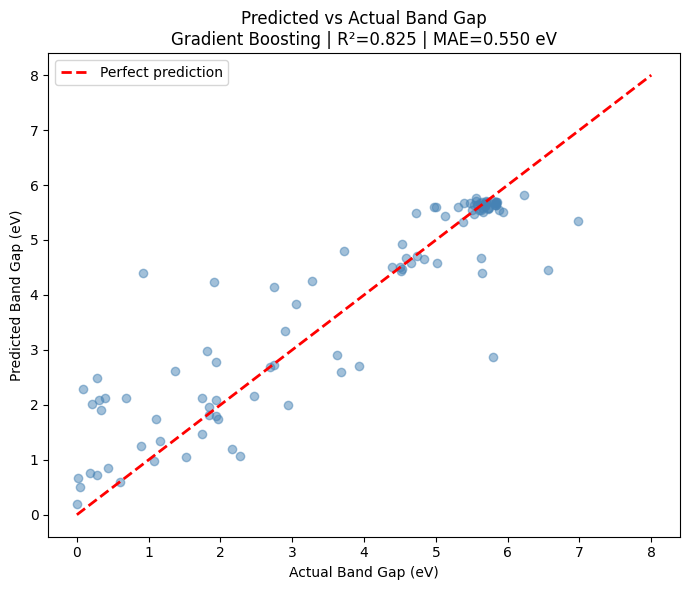

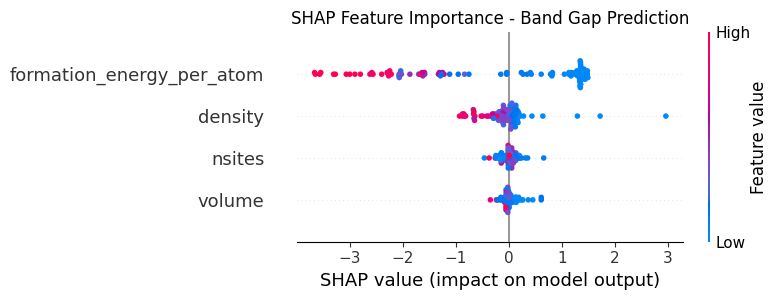

In [56]:
import shap

# Best model is Gradient Boosting
best_model = models['Gradient Boosting']
y_pred_best = best_model.predict(X_test_r)

# Predicted vs Actual plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test_r, y_pred_best, alpha=0.5, color='steelblue')
plt.plot([0, 8], [0, 8], 'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Band Gap (eV)')
plt.ylabel('Predicted Band Gap (eV)')
plt.title(f'Predicted vs Actual Band Gap\nGradient Boosting | R²=0.825 | MAE=0.550 eV')
plt.legend()
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP values
explainer = shap.Explainer(best_model, X_train_r)
shap_values = explainer(X_test_r)

plt.figure()
shap.summary_plot(shap_values, X_test_r, show=False)
plt.title('SHAP Feature Importance - Band Gap Prediction')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()